In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [3]:
# 시계열 종가 예측
df = pd.read_csv('../csv/AAPL.csv')

df = df[['Date', 'Adj Close', 'Volume']]
df.dropna(axis= 0, inplace=True)

In [4]:
X_all = df[['Adj Close', 'Volume']].astype('float').values
Y_all = df[['Adj Close']].astype('float').values

In [6]:
# 데이터의 분할 -> 4개의 데이터가 생성 -> 8:2
# train_test_split() 함수와 같은 부분
split_idx = int(len(df) * 0.8)

X_train, X_test = X_all[: split_idx], X_all[split_idx: ]
Y_train, Y_test = Y_all[: split_idx], Y_all[split_idx: ]

In [7]:
# 스케일링
# 스케일링 따로 사용 -> 마지막 예측 종가, 실제 종가 데이터의 원본으로 역변환을 편하게 하기 위해
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_sc = x_scaler.fit_transform(X_train)
X_test_sc = x_scaler.transform(X_test)

Y_train_sc = y_scaler.fit_transform(Y_train)
Y_test_sc = y_scaler.transform(Y_test)

In [11]:
# DataLoader에서 구간 데이터를 나눠주기 위한 DataSet 구성
class WindowDataset(Dataset):
    def __init__(self, _x, _y, _window):
        # _x : 독립
        # _y : 종속
        # window : 구간
        self.x = _x
        self.y = _y
        self.window = _window
        self.n = len(_x) - _window
    # DataLoader에서 사용되는 특수 메서드 정의 : __len__(), __getitem__()
    def __len__(self):
        return max(self.n, 1)
    
    def __getitem__(self, idx):
        # 입력데이터 (문제)
        x_window = self.x[idx : idx + self.window]
        # 타깃데이터 (정답)
        y_next = self.y[idx + self.window]
        # tensor 데이터로 변환 (self.x, self.y 를 array 형태로 받는다는 가정)
        # tensor() -> 텐셔형으로 데이터를 변환 (깊은 복사 -> 데이터를 각각의 다른 위치에 저장)
        # from_numpy() -> 텐서형으로 데이터를 변환(얕은 복사 -> 데이터의 위치는 같고 라벨을 추가)
        x_tensor = torch.from_numpy(x_window)
        y_tensor = torch.from_numpy(y_next)
        return x_tensor, y_tensor


class RNNReg(nn.Module):
    # 해당 class 에서 정의되는 함수는 생성자함수, forward() 함수
    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers = 1,
        nonlinearity = 'tanh',
        dropout = 0.0,
        bidirectional = False,
        batch_first = True
        # 매개변수를 입력한 이유 : 
    ):
        # 부모 클래스의 생성자 함수 호출
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size= hidden_size,
            num_layers= num_layers,
            nonlinearity= nonlinearity,
            dropout= dropout,
            bidirectional= bidirectional,
            batch_first= batch_first
        )
        # self.head = nn.Linear(hidden_size, 1) # 1차원 스칼라 회귀
        # bidirectional의 값이 False인 경우에는 hidden_size를 사용
        # 만약 True라면 hidden_size * 2
        out_features = hidden_size * (2 if bidirectional else 1)
        # 선형 학습 모델 -> 비선형 학습 모델
        # self.head = nn.Linear(out_features, 1)
        self.head = nn.Sequential(
            nn.Linear(out_features,out_features*2),
            nn.ReLU(),
            nn.Linear(out_features*2, 1)
        )
    def forward (self,x):
        # out -> 모든 시점에서의 은닉층의 값(결과)
        # h_n -> 마지막 시점에서의 은닉층의 값(결과) -> 층이 존재하면 층별 마지막 값 ->시계열 분석은 마지막 시점을 사용
        out, h_n = self.rnn(x)
        # 가장 마지막 은늑의 값을 사용(마지막 층의 값)
        last_hidden = h_n[-1]
        res = self.head(last_hidden)
        return res

In [12]:
X_train_sc

array([[-0.49256807,  0.26458163],
       [-0.49478753, -0.52628095],
       [-0.49774675, -0.71555134],
       ...,
       [ 4.61326595,  0.15829833],
       [ 4.52975378,  0.75572831],
       [ 4.40980077,  0.47664967]], shape=(7770, 2))

In [13]:
# 구간별 데이터셋을 구성
train_ds = WindowDataset(X_train_sc, Y_train_sc, 60)
test_ds = WindowDataset(X_test_sc, Y_test_sc, 60)

train_dl = DataLoader(train_ds, shuffle=True, drop_last=True, batch_size=64)
test_dl = DataLoader(test_ds, shuffle=False, drop_last=False, batch_size=256)

In [27]:
aapl_model = RNNReg(
    input_size=2, hidden_size=128
)

In [28]:
# 회귀 분석 -> 손실 함수 -> MSE
criterion = nn.MSELoss()
# 옵티마이저 설정
optimizer = torch.optim.Adam(aapl_model.parameters(), lr= 0.0001)
# loss의 미분 폭주 방지용 설정
max_grad_norm = 1.0

# 검증 단계 함수 생성
# @torch 데코레이터 함수 생성도 가능
def evaliate_mse(dataloader):
    aapl_model.eval()
    total_loss = 0.0
    total_n = 0
    with torch.no_grad():
        for x, y in dataloader:
            x = x.float()
            y = y.float()
            yhat = aapl_model(x)
            loss = criterion(yhat, y)
            # 총 손실
            total_loss += loss.item() * y.size(0)
            # loss.item() : 손실의 평균
            # y.size(0) : 개수
            total_n += y.size(0)
    return total_loss / max(total_n, 1)



In [29]:
# 반복 학습 루프

# 학습 데이터의 loss 들 검증 데이터의 loss 들을 저장 -> 시각화
train_history = []
val_history = []

for epoch in range(20):
    aapl_model.train()
    running = 0.0
    n_seen = 0

    for x, y in train_dl:
        x = x.float()
        y = y.float()

        optimizer.zero_grad()
        yhat = aapl_model(x)
        loss = criterion(yhat, y)
        loss.backward()
        # 미분값 폭주 방지
        nn.utils.clip_grad_norm_(aapl_model.parameters(), max_grad_norm)

        optimizer.step()

        running += loss.item() * y.size(0)
        n_seen += y.size(0)
    train_mse = running / max(n_seen, 1)
    val_mse = evaliate_mse(test_dl)
    train_history.append(train_mse)
    val_history.append(val_mse)
    print(f"Epoch : {epoch + 1}, train_mse : {round(train_mse, 7)}, \
          val_mse : {round(val_mse, 5)}")

Epoch : 1, train_mse : 0.3716851,           val_mse : 70.89072
Epoch : 2, train_mse : 0.0133117,           val_mse : 53.64059
Epoch : 3, train_mse : 0.0042114,           val_mse : 48.46238
Epoch : 4, train_mse : 0.0022014,           val_mse : 46.54511
Epoch : 5, train_mse : 0.0015687,           val_mse : 45.15099
Epoch : 6, train_mse : 0.001388,           val_mse : 44.38749
Epoch : 7, train_mse : 0.0012419,           val_mse : 43.16596
Epoch : 8, train_mse : 0.0011942,           val_mse : 42.11791
Epoch : 9, train_mse : 0.0011277,           val_mse : 41.40751
Epoch : 10, train_mse : 0.0010475,           val_mse : 40.79872
Epoch : 11, train_mse : 0.0010262,           val_mse : 40.3169
Epoch : 12, train_mse : 0.0009932,           val_mse : 39.33235
Epoch : 13, train_mse : 0.0009706,           val_mse : 38.98669
Epoch : 14, train_mse : 0.0009297,           val_mse : 38.08781
Epoch : 15, train_mse : 0.000857,           val_mse : 37.31034
Epoch : 16, train_mse : 0.0009185,           val_mse

In [30]:
# 검증 셋 예측의 값과 실제 값의 그래프 시각화
aapl_model.eval()

preds = []
trues = []

with torch.no_grad():
    for x,y in test_dl :
        x = x.float()
        y = y.float()
        yhat = aapl_model(x)
        preds.append(yhat.cpu())
        trues.append(y.cpu())

# preds, trues를 numpy 형태로 변환
preds = torch.cat(preds, dim=0).squeeze(-1).numpy()
trues = torch.cat(trues, dim=0).squeeze(-1).numpy()

In [31]:
# 스케일링 데이터를 다시 원본의 데이터셋으로 변경
# inverse_transfrom() : 스케일링 데이터를 원본으로 변경
preds_origin = y_scaler.inverse_transform(preds.reshape(-1,1)).squeeze()
trues_origin = y_scaler.inverse_transform(trues.reshape(-1,1)).squeeze()

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(preds[:600], label = 'Preds data')
plt.plot(trues[:600], label = 'True data')
plt.legend()
plt.grid(True)
plt.show()

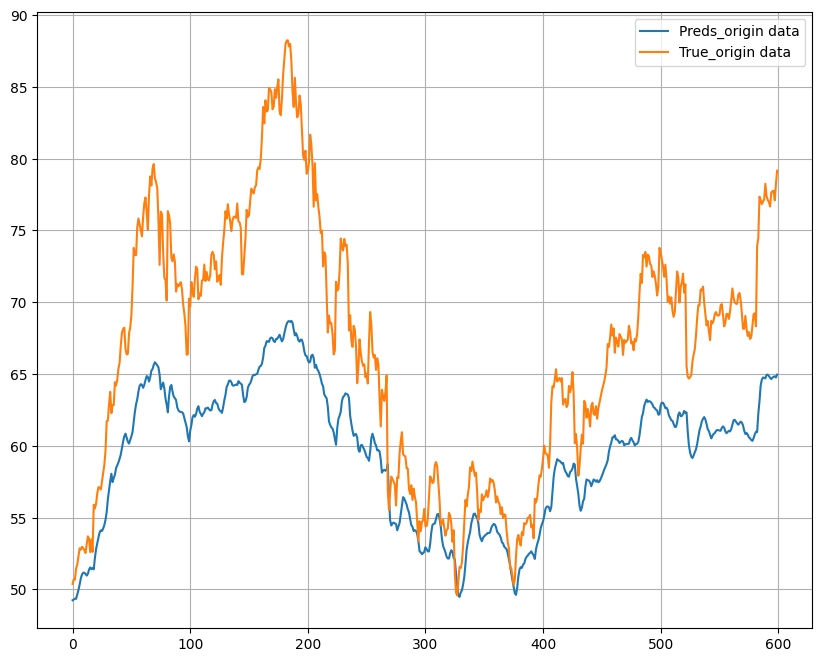

In [34]:
plt.figure(figsize=(10,8))
plt.plot(preds_origin[:600], label = 'Preds_origin data')
plt.plot(trues_origin[:600], label = 'True_origin data')
plt.legend()
plt.grid(True)
plt.show()